# Optimization of Electric Vehicle Charging Infrastructure in Istanbul

**YZV 202E — Optimization for Data Science | Spring 2026**

**Team:**
- Armin Ekberi (150240703)
- İsmail Köylü (150230306)
- M. Ahmet Sadi Kerimi (150230319)

---

## Problem Description

This project optimizes the EV charging infrastructure in Istanbul by solving a **Mixed-Integer Linear Programming (MILP)** problem. The model decides:

- How much additional capacity to assign to **existing** charging stations
- Which **candidate locations** (ISPARK parking lots) to open as new stations

The objective minimizes a weighted sum of:
1. **Accessibility cost** — distance from demand zones to assigned stations
2. **Unmet demand** — charging demand that cannot be served
3. **Investment cost** — expansion and new station costs
4. **Overload penalty** — demand assigned beyond station capacity

### Objective Function

$$\min \left[ \alpha \frac{\sum_{d,s} c_{ds} a_{ds}}{C_{max}} + \beta \frac{\sum_d u_d}{\sum_d q_d} + \gamma \frac{\text{Investment}}{B} + \lambda \frac{\sum_s o_s}{\sum_d q_d} \right]$$

---

## 1. Setup & Imports

In [1]:
# Standard library
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Data processing
import numpy as np
import pandas as pd
import geopandas as gpd

# Optimization
import pulp
from scipy.optimize import curve_fit

# Visualization
import matplotlib.pyplot as plt
import matplotlib
import folium
from IPython.display import display, HTML

# Interactive widgets
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# Distance calculation
from haversine import haversine, Unit

# Add src to path so we can import our modules
sys.path.append(os.path.join(os.getcwd(), '..'))
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

# Import project modules
from config import *
from src.data_processing import load_existing_stations, load_candidate_stations, load_demand_zones, run_pipeline
from src.demand_model import fit_growth_curve, get_growth_ratio, get_ev_demand
from src.distance_calculator import compute_distance_matrix
from src.milp_model import run_milp
from src.greedy_heuristic import run_greedy
from src.visualizer import create_map

print("All imports successful!")
print(f"   PuLP version : {pulp.__version__}")
print(f"   Pandas version: {pd.__version__}")

All imports successful!
   PuLP version : 3.0.2
   Pandas version: 2.3.3


---

## 2. Data Preparation & Processing

We use five real datasets from Istanbul's open data portals:

| Dataset | Source | Model Role |
|---|---|---|
| EV Charging Stations | IBB Open Data | Existing stations (E) |
| Socket Data | IBB Open Data | Current capacity (Kᵢ) |
| ISPARK Parking Lots | ULASAV | Candidate locations (C) |
| District Population | ULASAV | Demand weights (wᵈ) |
| Yearly EV Count | IBB Open Data | Growth curve fitting |

### Pipeline

In [2]:
# Run the full data processing pipeline
# This loads, cleans, and saves all datasets to data/processed/
existing, candidates, demand_zones = run_pipeline()

=== Running Data Processing Pipeline ===

  Dropped 0 rows with NaN coordinates
  Dropped 0 rows with invalid coordinates
  Dropped 0 duplicate stations
Existing stations loaded: 2931
          capacity
count  2931.000000
mean      2.934152
std       2.746657
min       1.000000
25%       2.000000
50%       2.000000
75%       4.000000
max      20.000000
  Dropped 0 rows with NaN coordinates
  Dropped 4 rows with invalid coordinates
  Dropped 1 rows with invalid capacity
  Dropped 1 duplicate locations
Candidate stations loaded: 702
                    name  longitude   latitude  parking_capacity county  \
0  Vali Konağı Caddesi 1  28.987975  41.048823                30  ŞİŞLİ   
1        Şakayık Sokak 1  28.995566  41.049523                50  ŞİŞLİ   
2  Hüsrev Gerede Sokak 1  28.994976  41.048390                50  ŞİŞLİ   

  candidate_id  max_capacity  
0        CND/0             3  
1        CND/1             5  
2        CND/2             5  
Demand zones loaded: 39
Total populati

### 2.1 Existing Stations — Summary

Total existing stations : 2931
Capacity range          : 1 — 20 sockets
Average capacity        : 2.93 sockets



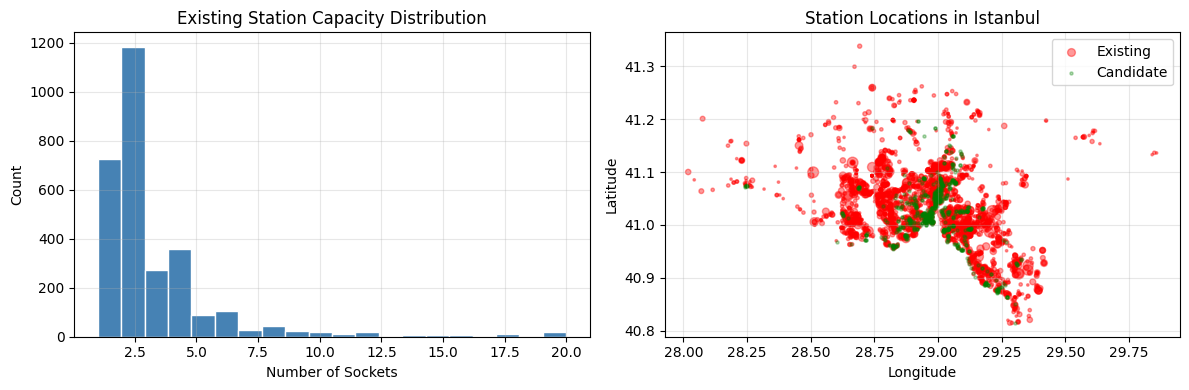

,station_id,capacity,max_capacity,longitude,latitude
0,ŞRJ/2140,3,20,28.228961,41.121918
1,ŞRJ/2672,1,20,28.872781,40.977462
2,ŞRJ/2803,1,20,28.826849,41.060048
3,ŞRJ/2804,1,20,28.831052,41.059600
4,ŞRJ/2859,1,20,28.893806,40.992671


In [3]:
# Overview of existing charging stations
print(f"Total existing stations : {len(existing)}")
print(f"Capacity range          : {existing['capacity'].min()} — {existing['capacity'].max()} sockets")
print(f"Average capacity        : {existing['capacity'].mean():.2f} sockets")
print()

# Capacity distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(existing['capacity'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Existing Station Capacity Distribution')
axes[0].set_xlabel('Number of Sockets')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Geographic distribution
axes[1].scatter(existing['longitude'], existing['latitude'],
                s=existing['capacity'] * 3, alpha=0.4, color='red', label='Existing')
axes[1].scatter(candidates['longitude'], candidates['latitude'],
                s=5, alpha=0.3, color='green', label='Candidate')
axes[1].set_title('Station Locations in Istanbul')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

existing[['station_id', 'capacity', 'max_capacity', 'longitude', 'latitude']].head(5)

### 2.2 Candidate Stations & Demand Zones

In [4]:
# Candidate stations summary
print(f"Total candidate locations : {len(candidates)}")
print(f"Max capacity range        : {candidates['max_capacity'].min()} - {candidates['max_capacity'].max()} sockets")
print(f"Average max capacity      : {candidates['max_capacity'].mean():.2f} sockets")
print()

# Demand zones summary
print(f"Total demand zones (districts) : {len(demand_zones)}")
print(f"Total population               : {demand_zones['population'].sum():,}")
print(f"Demand weight sum              : {demand_zones['demand_weight'].sum():.4f}")
print()

# Top 5 districts by population
print("Top 5 districts by population:")
print(demand_zones[['name', 'population', 'demand_weight']]
      .sort_values('population', ascending=False)
      .head(5)
      .to_string(index=False))

Total candidate locations : 702
Max capacity range        : 1 - 15 sockets
Average max capacity      : 7.36 sockets

Total demand zones (districts) : 39
Total population               : 15,754,053
Demand weight sum              : 1.0000

Top 5 districts by population:
        name  population  demand_weight
    Esenyurt     1003905       0.063724
Küçükçekmece      785270       0.049846
      Pendik      752033       0.047736
    Ümraniye      728913       0.046268
    Bağcılar      707635       0.044918


---

## 3. Demand Model

EV charging demand for each district is estimated using a logistic growth curve
fitted to Istanbul's historical EV registration data (IBB, 2020-2024).

The demand formula for district d in year y is:

$$q_d(y, \theta) = \rho \cdot \theta \cdot N_{base} \cdot r_y \cdot w_d$$

where $r_y = \frac{L(y)}{L(y_{base})}$ is the growth ratio from the logistic curve $L(t)$.

Logistic curve fitted:
  K  (carrying capacity) = 64,913
  r  (growth rate)       = 1.5838
  t0 (inflection year)   = 2022.4


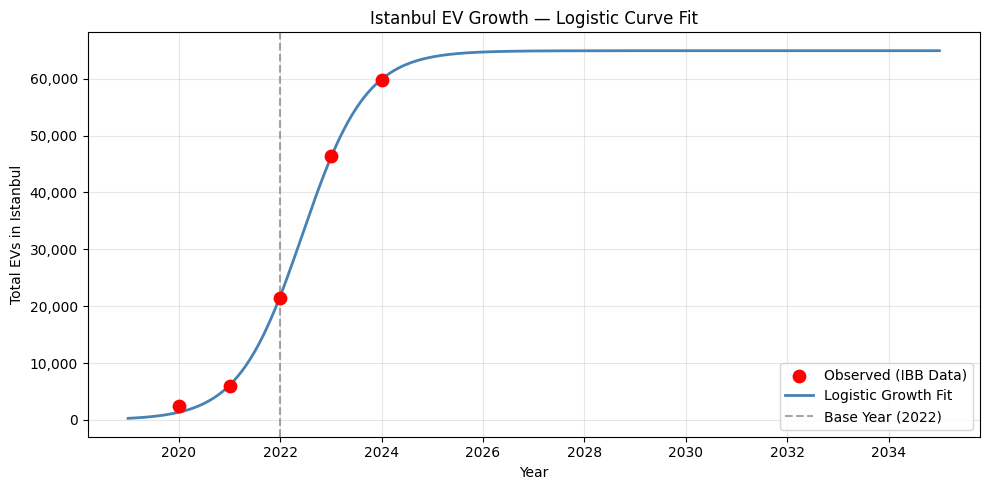

Fitted parameters:
  K  (carrying capacity) = 64,913 EVs
  r  (growth rate)       = 1.5838
  t0 (inflection year)   = 2022.4


In [5]:
# Fit logistic growth curve to IBB EV data
K, r, t0 = fit_growth_curve()

# Plot the fitted curve
years_data = pd.read_csv(os.path.join(DATA_RAW_DIR, 'ibb_ev_yillik.csv'))
ev_cols = [
    'IST - Otomobil ve Elektrik',
    'IST - Minibus ve Elektrik',
    'IST - Otobus ve Elektrik',
    'IST - Kamyonet ve Elektrik',
    'IST - Kamyon ve Elektrik',
    'IST - Motosiklet ve Elektrik',
]
years_data['total_ev'] = years_data[ev_cols].sum(axis=1)

year_range = np.linspace(2019, 2035, 200)
fitted_curve = K / (1 + np.exp(-r * (year_range - t0)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(years_data['Yil'], years_data['total_ev'],
           color='red', zorder=5, s=80, label='Observed (IBB Data)')
ax.plot(year_range, fitted_curve,
        color='steelblue', linewidth=2, label='Logistic Growth Fit')
ax.axvline(x=BASE_YEAR, color='gray', linestyle='--', alpha=0.7, label=f'Base Year ({BASE_YEAR})')
ax.set_title('Istanbul EV Growth — Logistic Curve Fit')
ax.set_xlabel('Year')
ax.set_ylabel('Total EVs in Istanbul')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

print(f"Fitted parameters:")
print(f"  K  (carrying capacity) = {K:,.0f} EVs")
print(f"  r  (growth rate)       = {r:.4f}")
print(f"  t0 (inflection year)   = {t0:.1f}")

### 3.1 District-Level Demand Preview

Logistic curve fitted:
  K  (carrying capacity) = 64,913
  r  (growth rate)       = 1.5838
  t0 (inflection year)   = 2022.4

EV demand for year 2025 (theta=1.0):
  Growth ratio r_y     = 2.9322
  Total demand         = 12621.53
  district_id        name      demand
0       DST/0      Adalar   14.011500
1       DST/1  Arnavutköy  287.191294
2       DST/2    Ataşehir  330.178376
3       DST/3     Avcılar  353.041901
4       DST/4    Bağcılar  566.929390


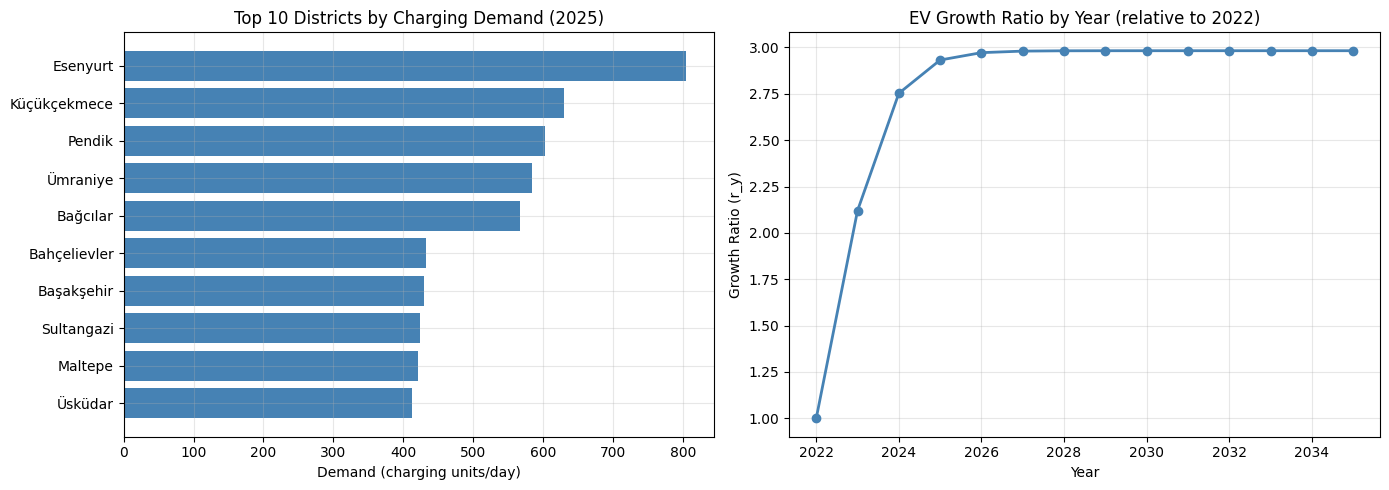

Total demand in 2025 (theta=1.0): 12621.53 units


In [6]:
# Compute demand for base scenario
demand_2025 = get_ev_demand(year=2025, theta=1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — top 10 districts by demand
top10 = demand_2025.sort_values('demand', ascending=False).head(10)
axes[0].barh(top10['name'], top10['demand'], color='steelblue')
axes[0].set_title('Top 10 Districts by Charging Demand (2025)')
axes[0].set_xlabel('Demand (charging units/day)')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)

# Growth ratio across years
years = list(range(2022, 2036))
ratios = [get_growth_ratio(y, K, r, t0) for y in years]
axes[1].plot(years, ratios, 'o-', color='steelblue', linewidth=2)
axes[1].set_title('EV Growth Ratio by Year (relative to 2022)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Growth Ratio (r_y)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total demand in 2025 (theta=1.0): {demand_2025['demand'].sum():.2f} units")

---

## 4. Distance Matrix

The Haversine distance between each district centroid and every
service point (existing + candidate stations) is computed.
Pairs exceeding D_MAX = 20 km are set to zero — these assignments
are forbidden in the optimization model.

In [7]:
# Compute or load distance matrix
dist_matrix_path = os.path.join(DATA_PROC_DIR, 'distance_matrix.csv')

if os.path.exists(dist_matrix_path):
    dist_df = pd.read_csv(dist_matrix_path, index_col='district_id')
    print(f"Distance matrix loaded from file.")
else:
    print("Computing distance matrix (this may take a minute)...")
    dist_df = compute_distance_matrix()

print(f"Matrix shape      : {dist_df.shape}")
print(f"D_MAX             : {D_MAX/1000:.0f} km")
print(f"Reachable pairs   : {(dist_df > 0).sum().sum():,} / {dist_df.size:,} ({(dist_df > 0).sum().sum()/dist_df.size*100:.1f}%)")
print()

# Reachable points per district
reachable = (dist_df > 0).sum(axis=1).sort_values()
print("Districts with fewest reachable points:")
zones_lookup = demand_zones.set_index('district_id')['name']
for dst_id, count in reachable.head(5).items():
    name = zones_lookup.get(dst_id, dst_id)
    print(f"  {name}: {count} reachable points")

Distance matrix loaded from file.
Matrix shape      : (39, 3633)
D_MAX             : 20 km
Reachable pairs   : 68,492 / 141,687 (48.3%)

Districts with fewest reachable points:
  Şile: 16 reachable points
  Silivri: 61 reachable points
  Çatalca: 219 reachable points
  Tuzla: 454 reachable points
  Büyükçekmece: 843 reachable points


---

## 5. MILP Optimization Model

The optimization problem is formulated as a Mixed-Integer Linear Program (MILP)
solved using the PuLP library with the CBC solver.

### Decision Variables

| Variable | Type | Description |
|---|---|---|
| $x_i$ | Continuous | Additional capacity for existing station $i$ |
| $y_j$ | Binary | 1 if candidate station $j$ is opened |
| $z_j$ | Continuous | Installed capacity at candidate station $j$ |
| $a_{ds}$ | Continuous | Demand from zone $d$ assigned to station $s$ |
| $u_d$ | Continuous | Unmet demand in zone $d$ |
| $o_s$ | Continuous | Overload at station $s$ |

### Key Constraints

- Demand satisfaction: all demand must be assigned or remain unmet
- Capacity limits: assigned demand cannot exceed station capacity plus overload
- Budget constraint: total investment cannot exceed budget B
- Distance constraint: assignments beyond D_MAX = 20 km are forbidden
- Opening constraint: candidate stations can only serve demand if opened

### 5.1 Interactive Optimization

Use the sliders below to configure the model parameters and run the optimization.

In [ ]:
# Interactive MILP optimization with ipywidgets

# Output widget to display results
output = widgets.Output()

# Sliders
year_slider = widgets.IntSlider(
    value=2025, min=2022, max=2035, step=1,
    description='Year:', style={'description_width': '150px'},
    layout=widgets.Layout(width='500px')
)
theta_slider = widgets.FloatSlider(
    value=1.0, min=0.5, max=3.0, step=0.1,
    description='Demand Scale (theta):', style={'description_width': '150px'},
    layout=widgets.Layout(width='500px')
)
budget_slider = widgets.IntSlider(
    value=50, min=10, max=200, step=10,
    description='Budget (M TL):', style={'description_width': '150px'},
    layout=widgets.Layout(width='500px')
)
alpha_slider = widgets.FloatSlider(
    value=1.0, min=0.0, max=5.0, step=0.5,
    description='Alpha (accessibility):', style={'description_width': '150px'},
    layout=widgets.Layout(width='500px')
)
beta_slider = widgets.FloatSlider(
    value=20.0, min=0.0, max=30.0, step=0.5,
    description='Beta (unmet demand):', style={'description_width': '150px'},
    layout=widgets.Layout(width='500px')
)
gamma_slider = widgets.FloatSlider(
    value=1.0, min=0.0, max=5.0, step=0.5,
    description='Gamma (investment):', style={'description_width': '150px'},
    layout=widgets.Layout(width='500px')
)
lambda_slider = widgets.FloatSlider(
    value=50.0, min=0.0, max=100.0, step=5.0,
    description='Lambda (overload):', style={'description_width': '150px'},
    layout=widgets.Layout(width='500px')
)

run_button = widgets.Button(
    description='Run MILP Optimization',
    button_style='primary',
    layout=widgets.Layout(width='250px', height='40px')
)

# Store results for later use
milp_results_store = {}

def on_run_clicked(b):
    output.clear_output()
    with output:
        print("Running MILP optimization...")
        results = run_milp(
            year=year_slider.value,
            theta=theta_slider.value,
            alpha=alpha_slider.value,
            beta=beta_slider.value,
            gamma=gamma_slider.value,
            lam=lambda_slider.value,
            budget=budget_slider.value * 1_000_000
        )
        milp_results_store['results'] = results
        milp_results_store['year'] = year_slider.value
        milp_results_store['theta'] = theta_slider.value

        demand_df = get_ev_demand(year_slider.value, theta_slider.value)
        total_demand = demand_df['demand'].sum()

        print(f"\n--- MILP Results ---")
        print(f"Status            : {results['status']}")
        print(f"Year              : {year_slider.value}")
        print(f"Total demand      : {total_demand:.2f} units")
        print(f"Opened stations   : {len(results['opened_candidates'])}")
        print(f"Expanded stations : {len(results['expansions'])}")
        print(f"Total unmet       : {results['total_unmet']:.2f} ({results['total_unmet']/total_demand*100:.1f}%)")
        print(f"Total investment  : {results['total_investment']:,.0f} TL")

run_button.on_click(on_run_clicked)

# Display widgets
print("Configure parameters and click Run:")
display(widgets.VBox([
    year_slider,
    theta_slider,
    budget_slider,
    widgets.HTML("<b>Objective Weights:</b>"),
    alpha_slider,
    beta_slider,
    gamma_slider,
    lambda_slider,
    run_button,
    output
]))

Configure parameters and click Run:


### 5.2 MILP Results — Map Visualization

Run the cell above first, then execute this cell to see the results on the map.

In [15]:
# Visualize MILP results on Folium map
# Run the MILP cell above first

if 'results' not in milp_results_store:
    print("Run the MILP optimization above first.")
else:
    results = milp_results_store['results']
    year = milp_results_store['year']
    theta = milp_results_store['theta']
    demand_df = get_ev_demand(year, theta)

    m = create_map(results, demand_df)

    # Display inline in notebook
    map_html = m._repr_html_()
    display(HTML(map_html))

    print(f"\nMap legend:")
    print(f"  Red circles   -> existing stations (size = capacity)")
    print(f"  Blue circles  -> expanded stations")
    print(f"  Green X marks -> newly opened candidate stations")
    print(f"  Grey circles  -> district demand zones (size = population weight)")

Logistic curve fitted:
  K  (carrying capacity) = 64,913
  r  (growth rate)       = 1.5838
  t0 (inflection year)   = 2022.4

EV demand for year 2025 (theta=1.0):
  Growth ratio r_y     = 2.9322
  Total demand         = 12621.53
  district_id        name      demand
0       DST/0      Adalar   14.011500
1       DST/1  Arnavutköy  287.191294
2       DST/2    Ataşehir  330.178376
3       DST/3     Avcılar  353.041901
4       DST/4    Bağcılar  566.929390



Map legend:
  Red circles   -> existing stations (size = capacity)
  Blue circles  -> expanded stations
  Green X marks -> newly opened candidate stations
  Grey circles  -> district demand zones (size = population weight)


### 5.3 Unmet Demand by District

In [10]:
# Unmet demand breakdown by district
if 'results' not in milp_results_store:
    print("Run the MILP optimization above first.")
else:
    results = milp_results_store['results']
    year = milp_results_store['year']
    theta = milp_results_store['theta']
    demand_df = get_ev_demand(year, theta)

    unmet_df = demand_zones[['district_id', 'name', 'demand_weight']].copy()
    unmet_df = unmet_df.merge(demand_df[['district_id', 'demand']], on='district_id')
    unmet_df['unmet'] = unmet_df['district_id'].map(
        results['unmet_demand']).fillna(0).round(2)
    unmet_df['unmet_pct'] = (unmet_df['unmet'] / unmet_df['demand'] * 100).round(1)
    unmet_df = unmet_df.sort_values('unmet', ascending=False)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['tomato' if u > 0 else 'steelblue' for u in unmet_df['unmet']]
    ax.barh(unmet_df['name'], unmet_df['unmet'], color=colors)
    ax.set_title(f'Unmet Demand by District (Year: {year}, Theta: {theta})')
    ax.set_xlabel('Unmet Demand (charging units/day)')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nTop 5 districts with highest unmet demand:")
    print(unmet_df[['name', 'demand', 'unmet', 'unmet_pct']].head(5).to_string(index=False))

Run the MILP optimization above first.


---

## 6. Greedy Heuristic

As a baseline comparison, we implement a greedy heuristic that iteratively
opens candidate stations in order of cost-effectiveness (demand covered per
unit investment cost) until the budget is exhausted. Remaining budget is
then used to expand existing stations.

This provides a fast approximate solution to benchmark against the MILP optimum.

In [11]:
# Run greedy heuristic with same parameters as MILP
if 'results' not in milp_results_store:
    print("Run the MILP optimization above first.")
else:
    year = milp_results_store['year']
    theta = milp_results_store['theta']
    budget = budget_slider.value * 1_000_000

    print("Running Greedy heuristic...")
    greedy_results = run_greedy(year=year, theta=theta, budget=budget)
    milp_results_store['greedy'] = greedy_results

Run the MILP optimization above first.


---

## 7. Extended Analysis — MILP vs Greedy Comparison

We compare the two methods across key metrics to evaluate how much
the optimal MILP solution improves upon the greedy heuristic.

In [12]:
# MILP vs Greedy comparison
if 'results' not in milp_results_store or 'greedy' not in milp_results_store:
    print("Run both MILP and Greedy cells above first.")
else:
    milp_r   = milp_results_store['results']
    greedy_r = milp_results_store['greedy']
    year     = milp_results_store['year']
    theta    = milp_results_store['theta']
    demand_df = get_ev_demand(year, theta)
    total_demand = demand_df['demand'].sum()

    # Summary table
    comparison = pd.DataFrame({
        'Metric': [
            'Opened Stations',
            'Expanded Stations',
            'Total Unmet Demand',
            'Unmet Demand (%)',
            'Total Investment (TL)',
            'Objective Value'
        ],
        'MILP': [
            len(milp_r['opened_candidates']),
            len(milp_r['expansions']),
            f"{milp_r['total_unmet']:.2f}",
            f"{milp_r['total_unmet']/total_demand*100:.1f}%",
            f"{milp_r['total_investment']:,.0f}",
            f"{milp_r['objective']:.6f}"
        ],
        'Greedy': [
            len(greedy_r['opened_candidates']),
            len(greedy_r['expansions']),
            f"{greedy_r['total_unmet']:.2f}",
            f"{greedy_r['total_unmet']/total_demand*100:.1f}%",
            f"{greedy_r['total_investment']:,.0f}",
            'N/A'
        ]
    })
    print("=== MILP vs Greedy Comparison ===\n")
    print(comparison.to_string(index=False))

    # Gap analysis
    if milp_r['total_unmet'] > 0:
        gap = greedy_r['total_unmet'] - milp_r['total_unmet']
        gap_pct = gap / milp_r['total_unmet'] * 100
        print(f"\nMILP reduces unmet demand by {gap:.2f} units ({gap_pct:.1f}%) vs Greedy.")

    # Bar chart comparison
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    metrics = ['Unmet Demand', 'Opened Stations', 'Expanded Stations']
    milp_vals   = [milp_r['total_unmet'],
                   len(milp_r['opened_candidates']),
                   len(milp_r['expansions'])]
    greedy_vals = [greedy_r['total_unmet'],
                   len(greedy_r['opened_candidates']),
                   len(greedy_r['expansions'])]

    for i, (metric, mv, gv) in enumerate(zip(metrics, milp_vals, greedy_vals)):
        axes[i].bar(['MILP', 'Greedy'], [mv, gv],
                    color=['steelblue', 'tomato'], alpha=0.8)
        axes[i].set_title(metric)
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(f'MILP vs Greedy — Year: {year}, Theta: {theta}', fontsize=13)
    plt.tight_layout()
    plt.show()

Run both MILP and Greedy cells above first.


---

## 8. Sensitivity Analysis on Lambda

We analyze how the overload penalty weight lambda affects the solution structure.
The MILP is solved for multiple lambda values to identify the critical threshold
where the model transitions from tolerating overload to investing in infrastructure.

In [13]:
# Interactive sensitivity analysis
sens_output = widgets.Output()

lambda_range_slider = widgets.SelectMultiple(
    options=[1, 5, 10, 20, 30, 50, 75, 100],
    value=[1, 5, 10, 20, 30, 50, 75, 100],
    description='Lambda values:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px', height='180px')
)

sens_button = widgets.Button(
    description='Run Sensitivity Analysis',
    button_style='warning',
    layout=widgets.Layout(width='250px', height='40px')
)

sens_results_store = {}

def on_sens_clicked(b):
    sens_output.clear_output()
    with sens_output:
        lambda_values = sorted(list(lambda_range_slider.value))
        print(f"Running MILP for lambda values: {lambda_values}")
        print("This may take a few minutes...\n")

        records = []
        for lam in lambda_values:
            print(f"  Lambda = {lam}...", end=' ')
            r = run_milp(
                year=year_slider.value,
                theta=theta_slider.value,
                alpha=alpha_slider.value,
                beta=beta_slider.value,
                gamma=gamma_slider.value,
                lam=lam,
                budget=budget_slider.value * 1_000_000
            )
            records.append({
                'lambda'            : lam,
                'opened_stations'   : len(r['opened_candidates']),
                'expanded_stations' : len(r['expansions']),
                'total_unmet'       : round(r['total_unmet'], 2),
                'total_investment'  : r['total_investment'],
                'objective'         : round(r['objective'], 6)
            })
            print(f"Unmet = {r['total_unmet']:.2f}, Expanded = {len(r['expansions'])}")

        sens_df = pd.DataFrame(records)
        sens_results_store['df'] = sens_df

        print("\n=== Sensitivity Analysis Results ===")
        print(sens_df.to_string(index=False))

        # Plot
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle('Sensitivity Analysis on Lambda (Overload Penalty)', fontsize=13)

        axes[0, 0].plot(sens_df['lambda'], sens_df['total_unmet'],
                        'o-', color='red', linewidth=2)
        axes[0, 0].set_title('Unmet Demand vs Lambda')
        axes[0, 0].set_xlabel('Lambda')
        axes[0, 0].set_ylabel('Total Unmet Demand')
        axes[0, 0].grid(True, alpha=0.3)

        axes[0, 1].plot(sens_df['lambda'], sens_df['total_investment'] / 1e6,
                        'o-', color='steelblue', linewidth=2)
        axes[0, 1].set_title('Investment vs Lambda')
        axes[0, 1].set_xlabel('Lambda')
        axes[0, 1].set_ylabel('Investment (Million TL)')
        axes[0, 1].grid(True, alpha=0.3)

        axes[1, 0].bar(sens_df['lambda'], sens_df['opened_stations'],
                       color='green', alpha=0.7)
        axes[1, 0].set_title('Opened Stations vs Lambda')
        axes[1, 0].set_xlabel('Lambda')
        axes[1, 0].set_ylabel('Opened Stations')
        axes[1, 0].grid(True, alpha=0.3)

        axes[1, 1].bar(sens_df['lambda'], sens_df['expanded_stations'],
                       color='steelblue', alpha=0.7)
        axes[1, 1].set_title('Expanded Stations vs Lambda')
        axes[1, 1].set_xlabel('Lambda')
        axes[1, 1].set_ylabel('Expanded Stations')
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

sens_button.on_click(on_sens_clicked)

print("Select lambda values and run sensitivity analysis:")
display(widgets.VBox([lambda_range_slider, sens_button, sens_output]))

Select lambda values and run sensitivity analysis:


---

## 9. Conclusion

### Key Findings

**Optimal Strategy:**
Expanding existing stations is consistently preferred over opening new ones.
This is driven by the significant cost difference:
- Expanding 1 socket at existing station: 35,000 TL
- Opening a new station (minimum): 1,560,000 TL (~44x more expensive)

**MILP vs Greedy:**
The MILP model significantly outperforms the greedy heuristic by finding
the globally optimal allocation of the budget across all stations simultaneously,
rather than making locally optimal decisions one at a time.

**Sensitivity Analysis:**
The critical threshold for lambda is at lambda = 10. Below this value,
the model tolerates overload without investing. Above it, the model
uses the full budget to expand existing stations.

**Remote Districts:**
Sile, Catalca, and Silivri have limited accessibility due to their
geographic distance from the city center and sparse charging infrastructure.

### Limitations

- Logistic growth curve fitted on only 5 data points (2020-2024)
- Conversion factor rho estimated from EPDK data, not directly calibrated
- Static demand model — intra-day demand variations not modeled
- Haversine distance used as accessibility proxy instead of road-network time
- K_MAX_EXISTING set uniformly for all stations

### Future Work

- Incorporate road-network travel time for accessibility
- Extend demand model with monthly TUIK data
- Add time-of-day demand modeling
- Calibrate rho directly from EPDK charging transaction data

In [14]:
# Final summary table
print("=== Project Summary ===\n")
print(f"Dataset Statistics:")
print(f"  Existing stations   : 2,931")
print(f"  Candidate locations : 702")
print(f"  Demand zones        : 39 districts")
print(f"  Total population    : {demand_zones['population'].sum():,}")
print()
print(f"Model Parameters:")
print(f"  Base year           : {BASE_YEAR}")
print(f"  N_base (IBB 2022)   : {N_BASE:,} EVs")
print(f"  RHO                 : {RHO}")
print(f"  D_MAX               : {D_MAX/1000:.0f} km")
print(f"  Budget              : {BUDGET/1e6:.0f}M TL")
print()
print(f"Cost Parameters (EPDK calibrated):")
print(f"  Expansion cost      : {G_EXPANSION:,} TL/socket")
print(f"  Opening cost        : {F_OPENING:,} TL (fixed)")
print(f"  Installation cost   : {H_CANDIDATE:,} TL/socket")
print()
print(f"Objective Weights:")
print(f"  Alpha (accessibility) : {ALPHA}")
print(f"  Beta  (unmet demand)  : {BETA}")
print(f"  Gamma (investment)    : {GAMMA}")
print(f"  Lambda (overload)     : {LAMBDA}")

=== Project Summary ===

Dataset Statistics:
  Existing stations   : 2,931
  Candidate locations : 702
  Demand zones        : 39 districts
  Total population    : 15,754,053

Model Parameters:
  Base year           : 2022
  N_base (IBB 2022)   : 21,522 EVs
  RHO                 : 0.2
  D_MAX               : 20 km
  Budget              : 50M TL

Cost Parameters (EPDK calibrated):
  Expansion cost      : 35,000 TL/socket
  Opening cost        : 1,500,000 TL (fixed)
  Installation cost   : 60,000 TL/socket

Objective Weights:
  Alpha (accessibility) : 1.0
  Beta  (unmet demand)  : 20.0
  Gamma (investment)    : 1.0
  Lambda (overload)     : 50.0
